STEP 1: Import Required Libraries

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import ssl

STEP 2: Load Image from Google Drive

In [8]:
# ✅ Convert "view" link to "download" link:
# https://drive.google.com/file/d/1Mb2EDKbFdj_Lw3Qr0RvYIf3lRpJsezTr/view?usp=sharing
image_url = "https://drive.google.com/uc?export=download&id=1Mb2EDKbFdj_Lw3Qr0RvYIf3lRpJsezTr"

# Load image via URL (for Colab)
context = ssl._create_unverified_context()
resp = urllib.request.urlopen(image_url, context=context)
image_np = np.asarray(bytearray(resp.read()), dtype="uint8")
image = cv2.imdecode(image_np, cv2.IMREAD_COLOR)

if image is None:
    raise Exception("❌ Could not load image.")
else:
    print("✅ Image loaded successfully.")

# Make a copy for visualization
original = image.copy()

✅ Image loaded successfully.


Step 3: Preprocessing — Grayscale + Canny Edge Detection

In [9]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur to smooth noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Apply Canny edge detection
edges = cv2.Canny(blurred, 50, 200)

Step 4: Contour Detection to Find Document

array([[[246, 246, 252],
        [237, 237, 243],
        [219, 221, 229],
        ...,
        [139, 165, 189],
        [136, 162, 186],
        [132, 158, 182]],

       [[253, 253, 255],
        [250, 250, 255],
        [244, 247, 252],
        ...,
        [136, 162, 186],
        [133, 159, 183],
        [131, 157, 181]],

       [[239, 242, 246],
        [239, 242, 246],
        [245, 248, 252],
        ...,
        [133, 159, 183],
        [132, 158, 182],
        [132, 158, 182]],

       ...,

       [[151, 139, 129],
        [160, 148, 138],
        [154, 142, 132],
        ...,
        [176, 166, 156],
        [163, 153, 143],
        [176, 166, 156]],

       [[138, 126, 116],
        [148, 136, 126],
        [147, 135, 125],
        ...,
        [166, 156, 146],
        [164, 154, 144],
        [169, 159, 149]],

       [[137, 125, 115],
        [160, 148, 138],
        [142, 130, 120],
        ...,
        [177, 167, 157],
        [190, 180, 170],
        [175, 165, 155]]], dtype=uint8)
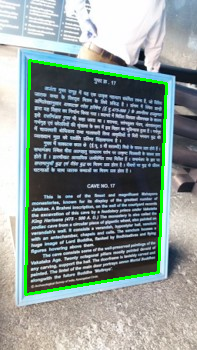

In [10]:
contours, _ = cv2.findContours(edges.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)

# Approximate contour with 4 corners (quadrilateral)
doc_contour = None
for cnt in contours:
    peri = cv2.arcLength(cnt, True)

    # Formula for polygonal approximation
    # approxPolyDP(curve, epsilon, closed)
    # epsilon = % of arc length (2% here)
    approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)

    if len(approx) == 4:
        doc_contour = approx
        break

if doc_contour is None:
    raise Exception("❌ Document contour not found.")

# Draw contour for visualization
cv2.drawContours(image, [doc_contour], -1, (0, 255, 0), 2)

Step 5: Reorder Points for Homography

    📘 Homography finds a perspective warp H such that: dst = H * src

In [11]:
def order_points(pts):
    """
    Orders the 4 points in consistent order:
    top-left, top-right, bottom-right, bottom-left
    """
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)       # top-left = min(s), bottom-right = max(s)
    diff = np.diff(pts, axis=1)  # top-right = min(diff), bottom-left = max(diff)

    rect[0] = pts[np.argmin(s)]     # top-left
    rect[2] = pts[np.argmax(s)]     # bottom-right
    rect[1] = pts[np.argmin(diff)]  # top-right
    rect[3] = pts[np.argmax(diff)]  # bottom-left
    return rect

pts = doc_contour.reshape(4, 2)
src_pts = order_points(pts)

Step 6: Define Destination Points (Rectified Rectangle)

In [12]:
# Compute width and height of new rectangle using Euclidean distance
widthA = np.linalg.norm(src_pts[2] - src_pts[3])  # br - bl
widthB = np.linalg.norm(src_pts[1] - src_pts[0])  # tr - tl
maxWidth = max(int(widthA), int(widthB))

heightA = np.linalg.norm(src_pts[1] - src_pts[2])  # tr - br
heightB = np.linalg.norm(src_pts[0] - src_pts[3])  # tl - bl
maxHeight = max(int(heightA), int(heightB))

# Destination points (rectangle)
dst_pts = np.array([
    [0, 0],
    [maxWidth - 1, 0],
    [maxWidth - 1, maxHeight - 1],
    [0, maxHeight - 1]
], dtype="float32")

Step 7: Homography Matrix & Warping

    Formula for homography matrix H:
        dst = H * src
        where H is 3x3 matrix mapping points from original to destination

In [13]:
# Get homography matrix
H = cv2.getPerspectiveTransform(src_pts, dst_pts)

# Apply warp using H to get the rectified image
warped = cv2.warpPerspective(original, H, (maxWidth, maxHeight))

Step 8: Display Results

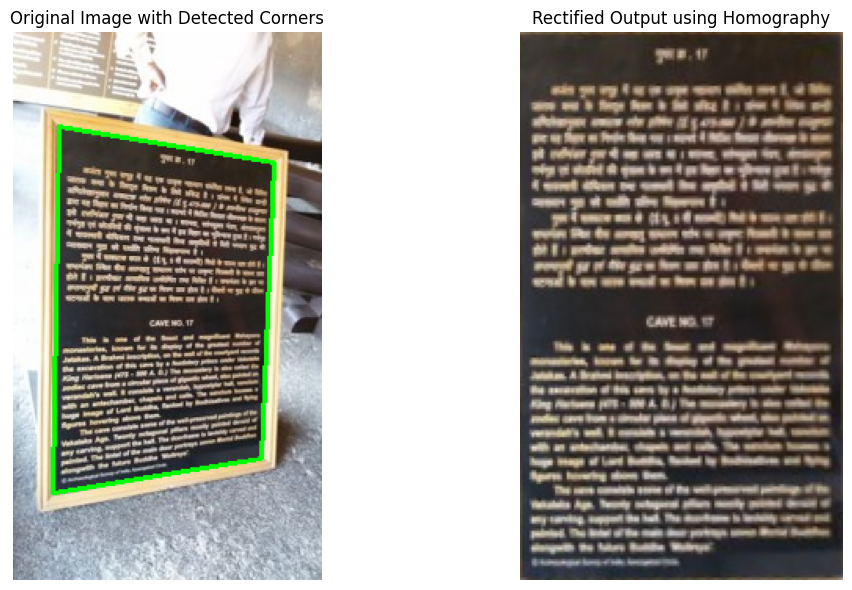

In [14]:
plt.figure(figsize=(12, 6))

# Show original with contour
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image with Detected Corners")
plt.axis("off")

# Show homography output
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
plt.title("Rectified Output using Homography")
plt.axis("off")

plt.tight_layout()
plt.show()

Step 9: Apply Sharpening Filter to Rectified Image

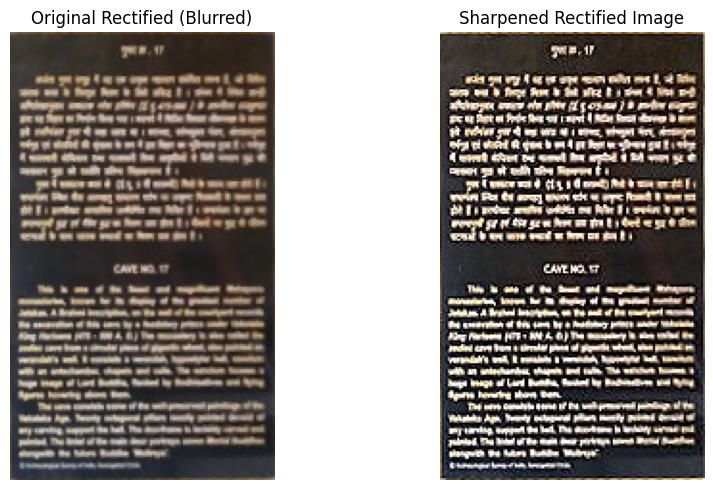

In [15]:
# Define sharpening kernel
sharpen_kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

# Apply filter using convolution
sharpened = cv2.filter2D(warped, -1, sharpen_kernel)

# Display side-by-side comparison
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
plt.title("Original Rectified (Blurred)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB))
plt.title("Sharpened Rectified Image")
plt.axis("off")

plt.tight_layout()
plt.show()